# FOVs as vectors in rule space  -  positive rules

Each FOV is a row of rule strengths; PCA asks which FOVs have similar rules.


In [1]:
import os
import sys

sys.path.append(os.path.abspath('../..'))   # project root
sys.path.append(os.path.abspath('..'))            # shared helpers, one level up

import rule_space_helper as rs
# Which mining run: data_helper.RESULT_CSV_PATH, shared by every notebook.
# To read a different one, pass its path to dh.load_results / rs.load below.


In [2]:
# --- Settings for this run. Everything else is left at the helper's default. ---
rs.METRIC            = 'Lift'
rs.POSITIVE_ONLY     = True
rs.RULE_MAX_ITEMS    = 2
rs.NO_SELF           = False
rs.MIN_FOV_THRESHOLD = 0.1
rs.SCORE_COL         = 'Pathological score'

data = rs.load()


Dropped 21 FOVs: Control_S


Loaded 598093 cells; FOVs: 267, biopsies: 73, patients: 71


Read results_CN_pairwise.csv + results_CN_complex.csv
Loaded 1190114 rules.


Kept 489672 rules at FDR <= 0.05.
Kept 102887 rules that add information.


Kept 101021 rules naming no Unidentified.


Kept 101021 rules (max_items=4, kind=None).


## 1. All FOVs

Every stage and both organs. The two scatters are the same PCA coloured twice, so they can be compared directly.


both organs, all stages: 263 FOVs x 39 columns  |  PC1 12.6%  PC2 7.7%


saved summary_downloads\pos_all_pca_organ.pdf


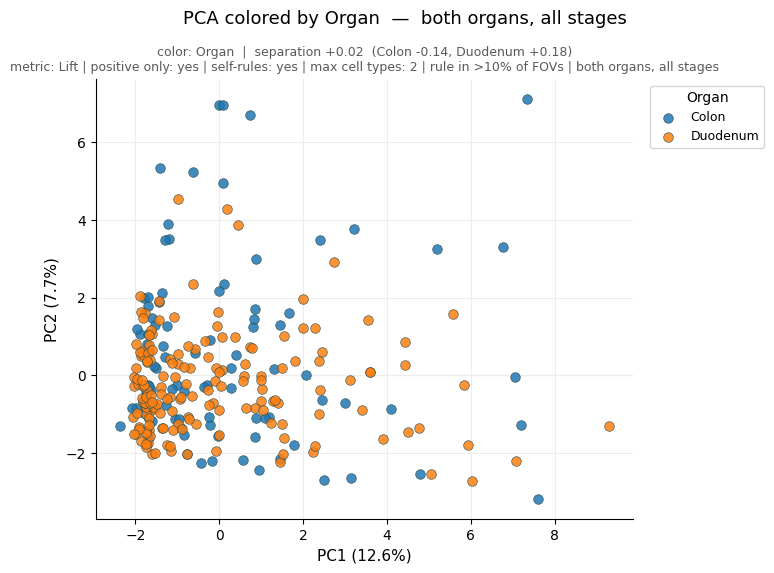

In [3]:
all_fovs = rs.run(data,
                   prefix='pos_all', diagnostics=False)

rs.scatter(all_fovs, color_by='Organ', save=True);   # the clean PCA, no labels

## 1.1. Colon, all stages

Every stage of one organ. The colourings below are the biopsy metadata - days after the
transplant, donor type, cortico response, survival - which need all the stages present to
be worth asking about.


Colon, all stages: 94 FOVs x 36 columns  |  PC1 14.4%  PC2 11.5%


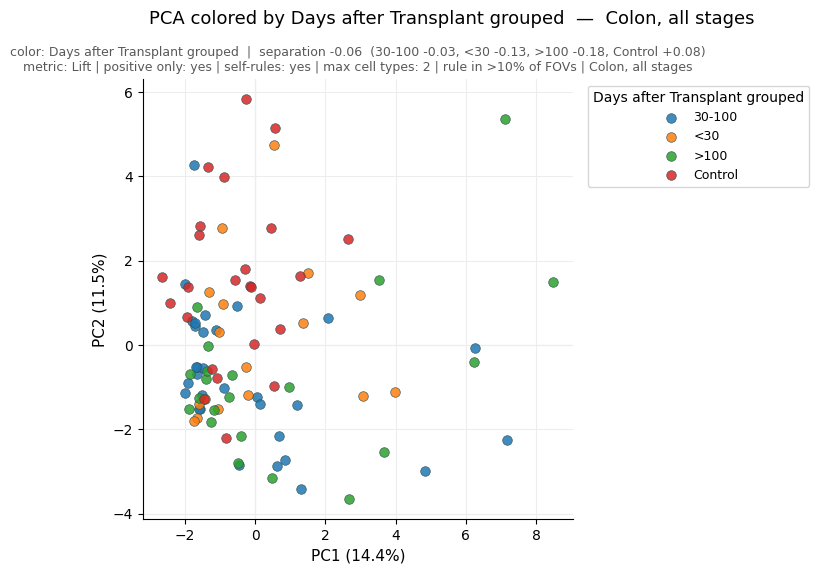

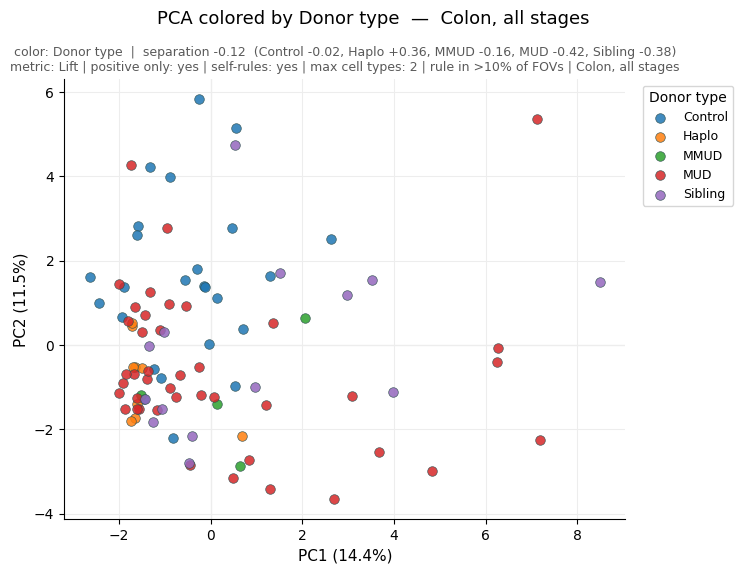

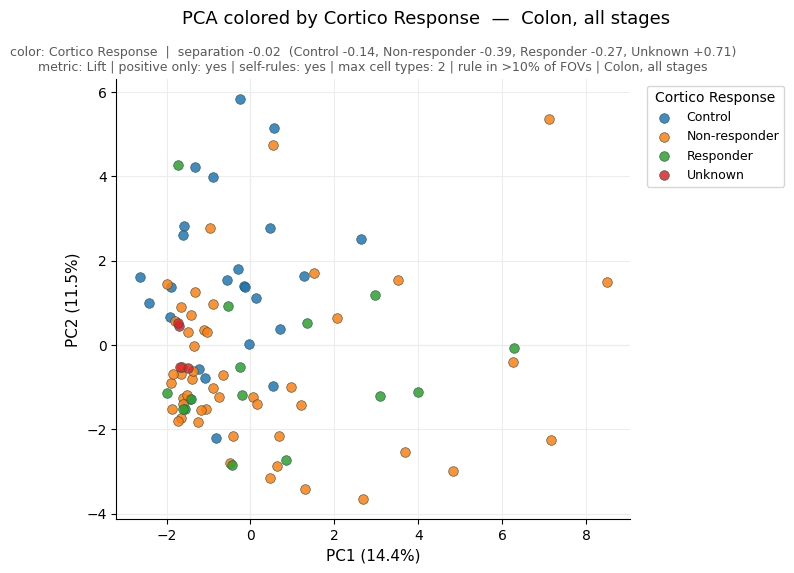

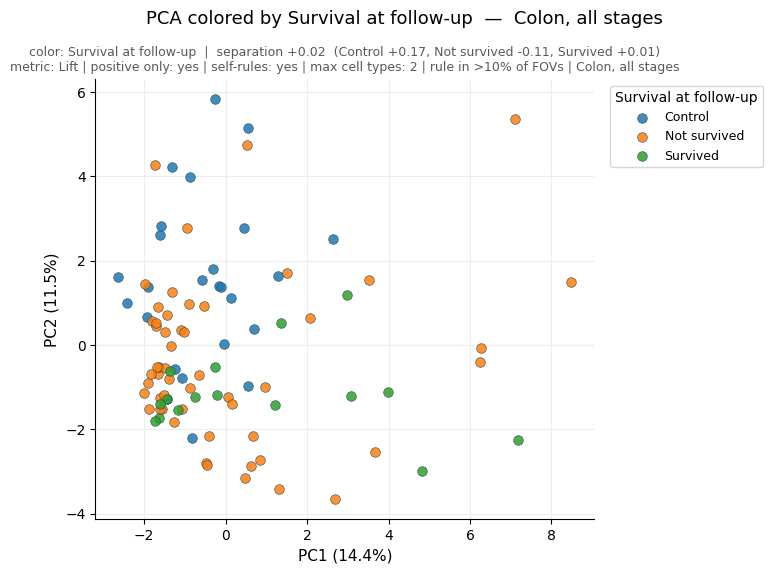

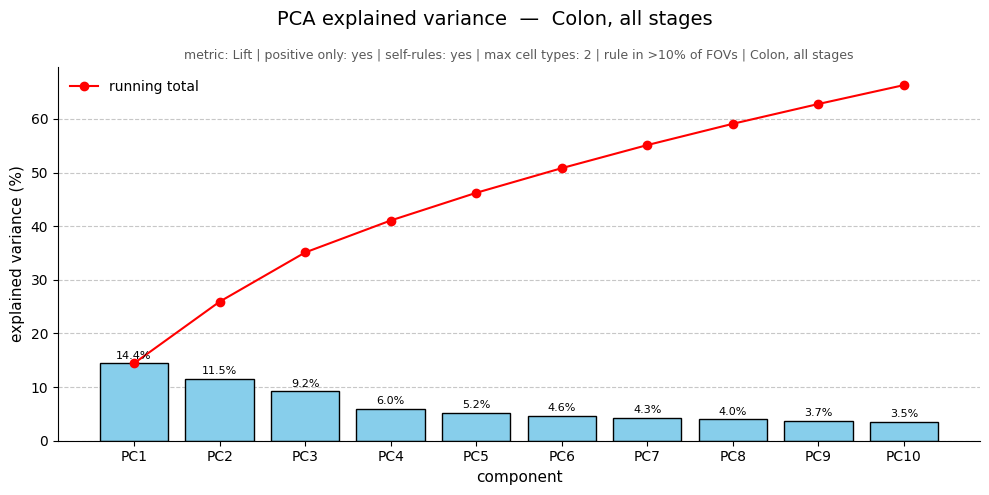

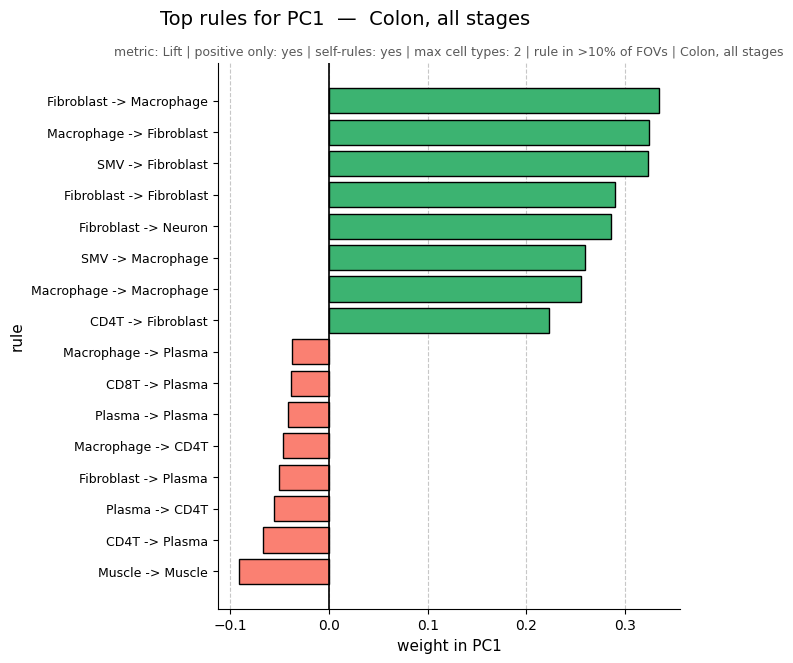

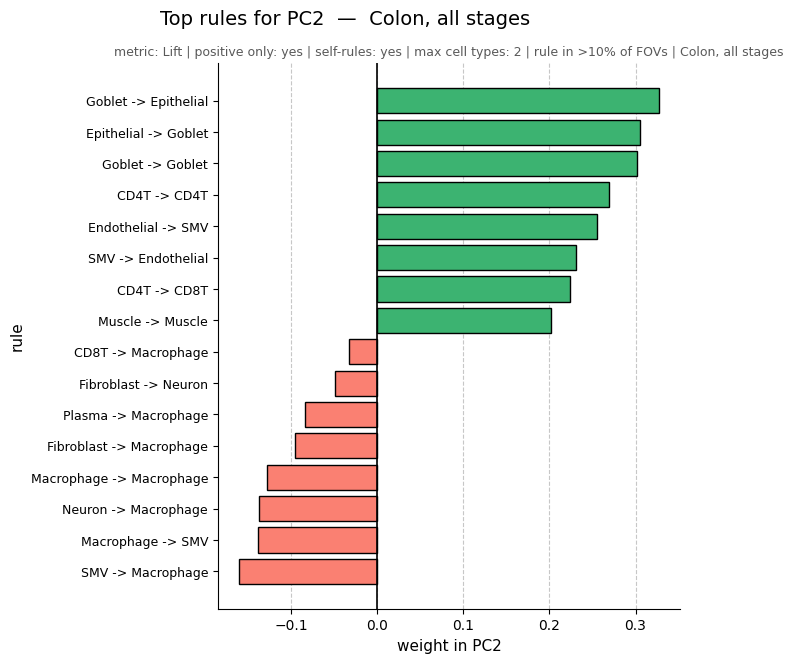

In [4]:
colon_all = rs.run(data,
                    organs=['Colon'], prefix='pos_colon',
                    colors=rs.METADATA_COLORS)


## 1.2. Duodenum, all stages

Every stage of one organ. The colourings below are the biopsy metadata - days after the
transplant, donor type, cortico response, survival - which need all the stages present to
be worth asking about.


Duodenum, all stages: 168 FOVs x 42 columns  |  PC1 13.5%  PC2 7.1%


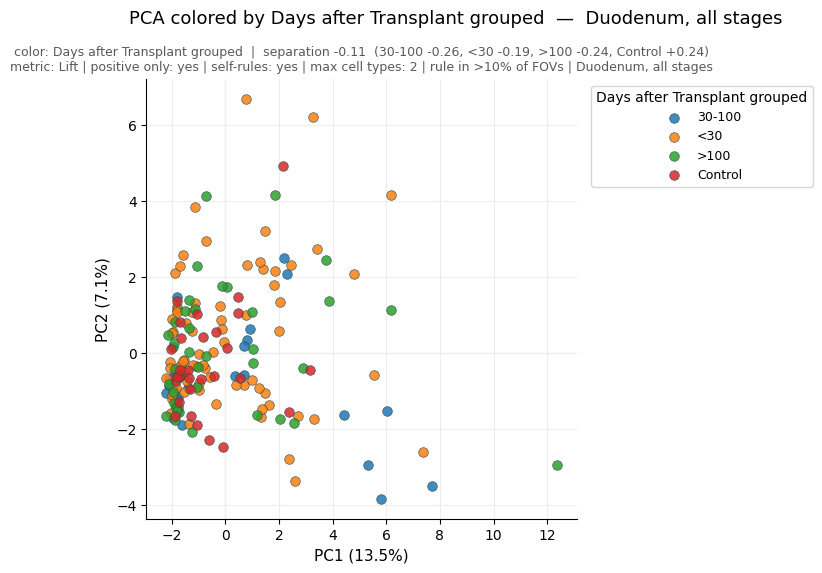

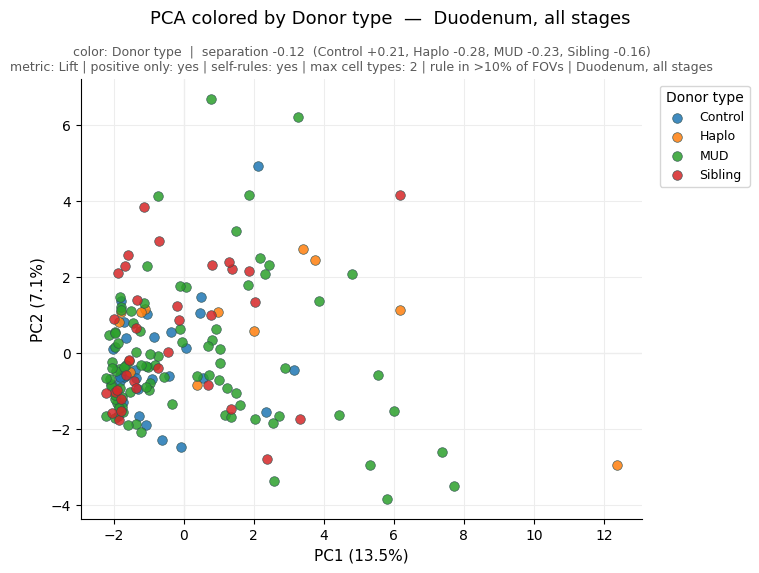

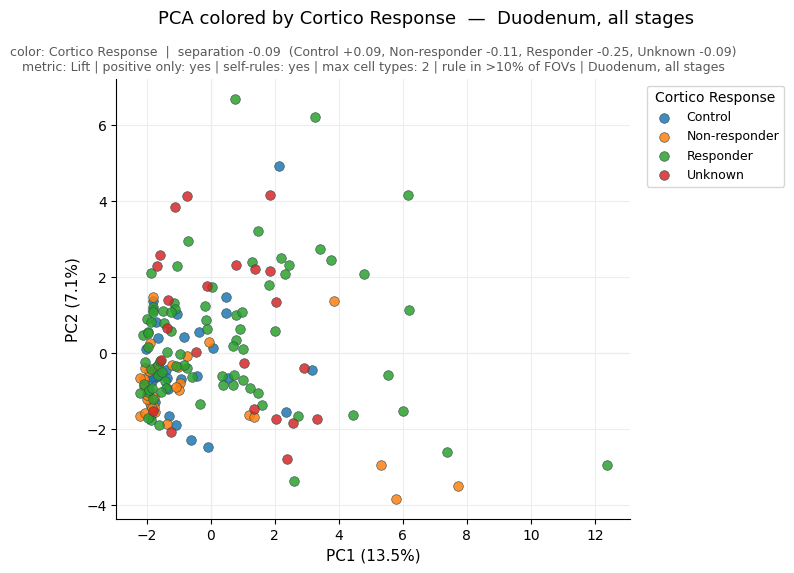

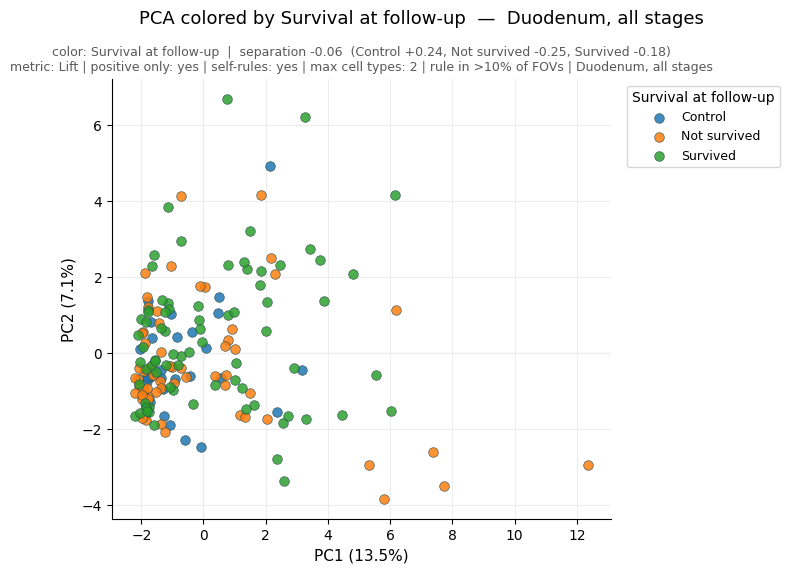

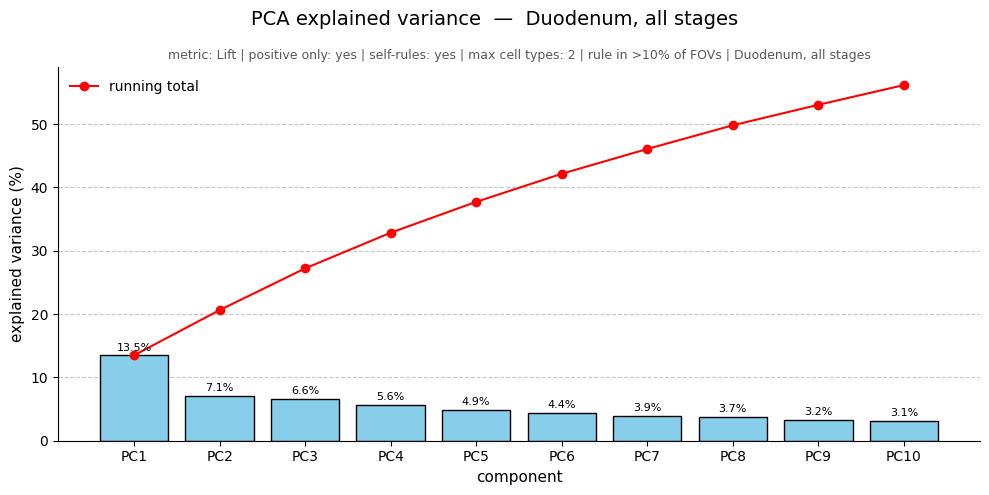

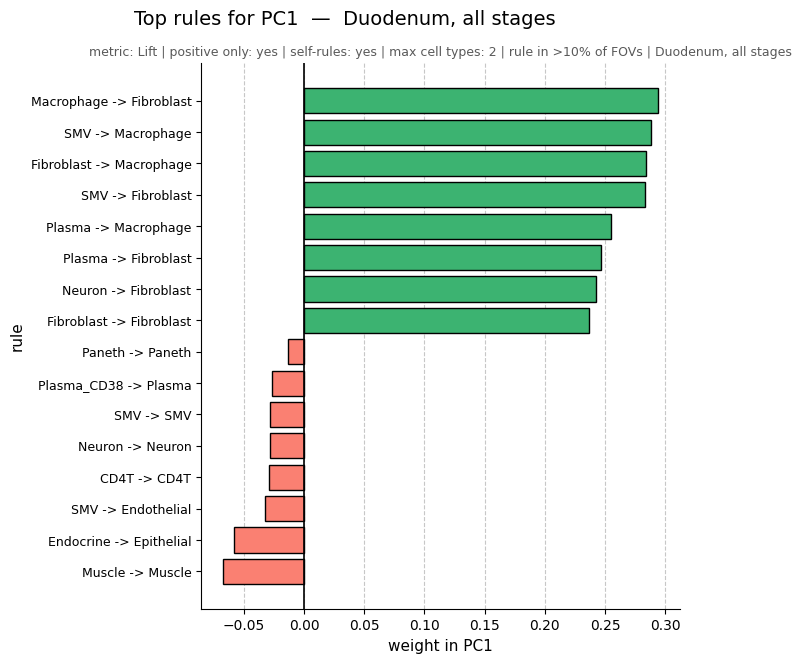

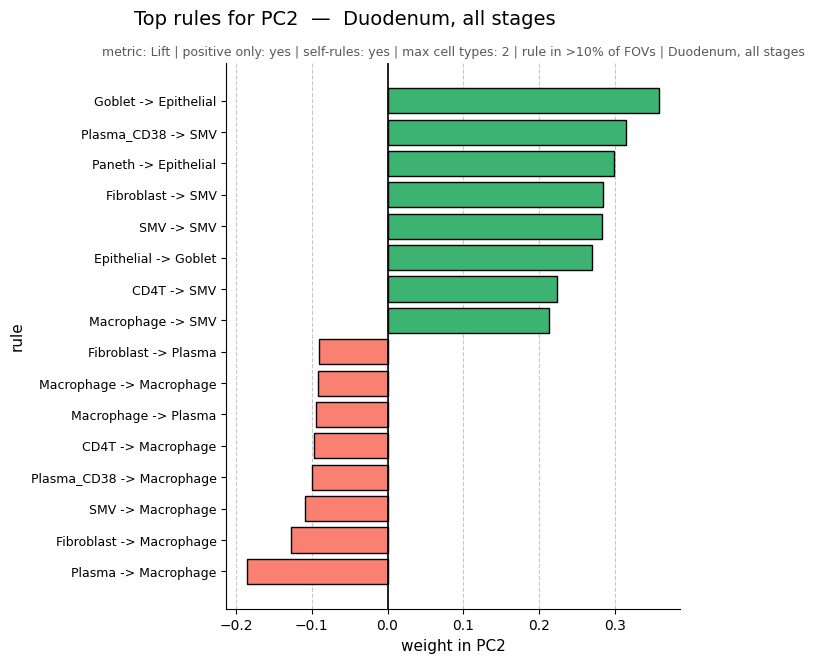

In [5]:
duodenum_all = rs.run(data,
                       organs=['Duodenum'], prefix='pos_duodenum',
                       colors=rs.METADATA_COLORS)


## 2. Colon, Control vs Severe

The two extreme stages inside one organ, so neither organ nor the middle stages can explain a split.


In [6]:
control_severe_colon = rs.run(data,
                               stages=['Control', 'Severe'], organs=['Colon'],
                               prefix='pos_cs_colon', diagnostics=False)


Colon, Control vs Severe: 55 FOVs x 44 columns  |  PC1 14.5%  PC2 10.7%


saved summary_downloads\pos_cs_colon_pca_pathological_score.pdf


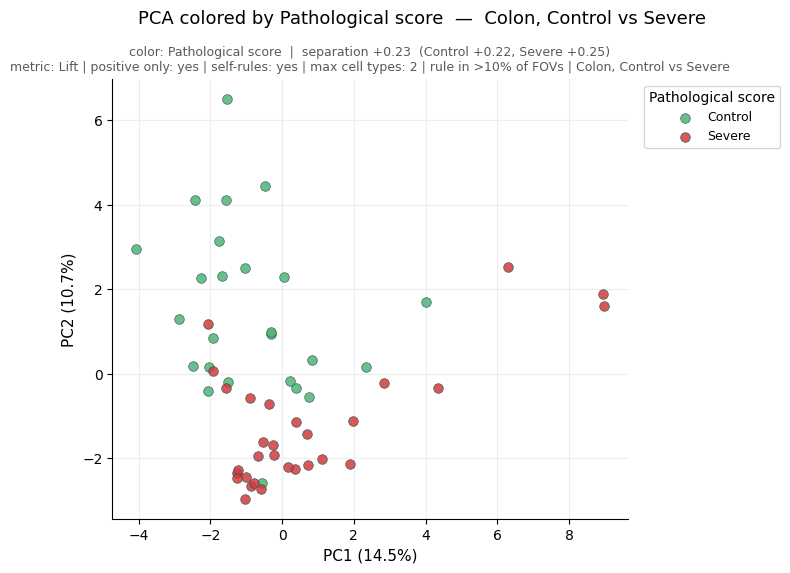

In [7]:
rs.scatter(control_severe_colon, save=True);   # the clean PCA, no labels

## 3. Duodenum, Control vs Severe

The same two stages in the other organ.


In [8]:
control_severe_duodenum = rs.run(data,
                                  stages=['Control', 'Severe'], organs=['Duodenum'],
                                  prefix='pos_cs_duodenum', diagnostics=False)


Duodenum, Control vs Severe: 67 FOVs x 28 columns  |  PC1 12.1%  PC2 11.5%


saved summary_downloads\pos_cs_duodenum_pca_pathological_score.pdf


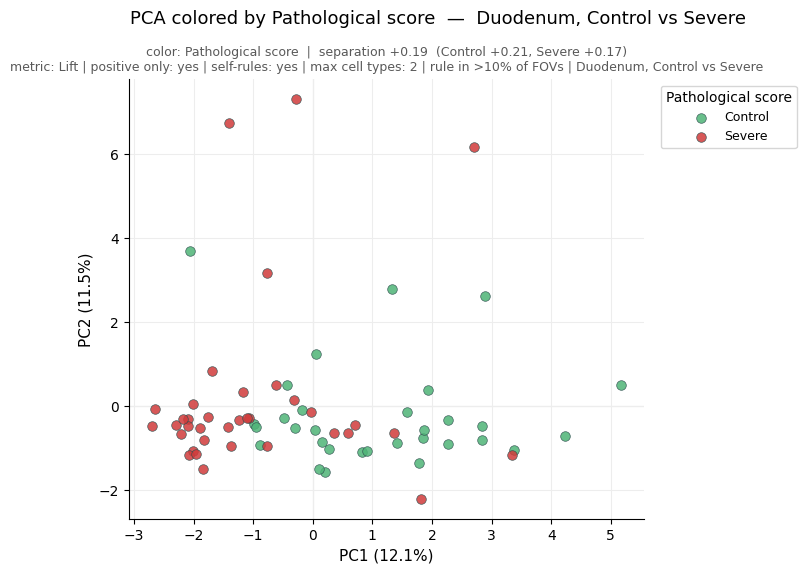

In [9]:
rs.scatter(control_severe_duodenum, save=True);   # the clean PCA, no labels

## 4. Colon, Mild vs Severe

The two disease stages, without the healthy controls.


In [10]:
mild_severe_colon = rs.run(data,
                            stages=['Mild', 'Severe'], organs=['Colon'],
                            prefix='pos_ms_colon', diagnostics=False)


Colon, Mild vs Severe: 69 FOVs x 33 columns  |  PC1 18.7%  PC2 11.6%


saved summary_downloads\pos_ms_colon_pca_pathological_score.pdf


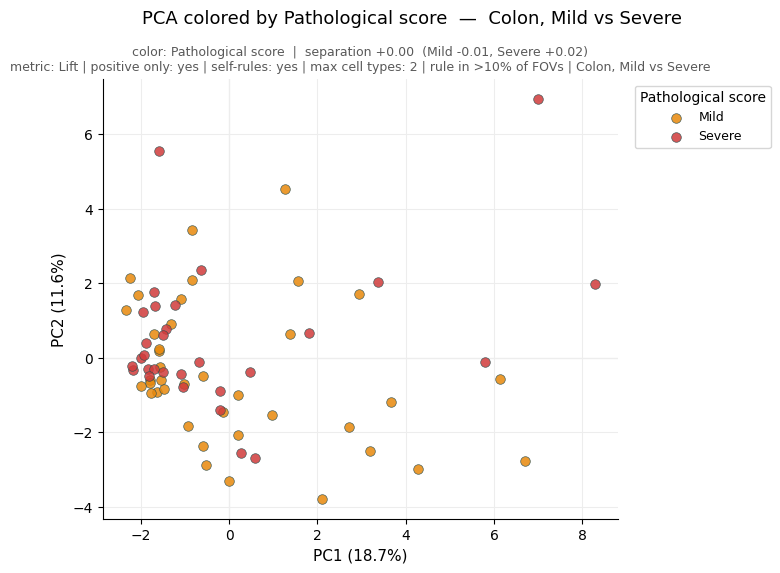

In [11]:
rs.scatter(mild_severe_colon, save=True);   # the clean PCA, no labels

## 5. Duodenum, Mild vs Severe

The same two stages in the other organ.


In [12]:
mild_severe_duodenum = rs.run(data,
                               stages=['Mild', 'Severe'], organs=['Duodenum'],
                               prefix='pos_ms_duodenum', diagnostics=False)


Duodenum, Mild vs Severe: 137 FOVs x 44 columns  |  PC1 14.0%  PC2 6.9%


saved summary_downloads\pos_ms_duodenum_pca_pathological_score.pdf


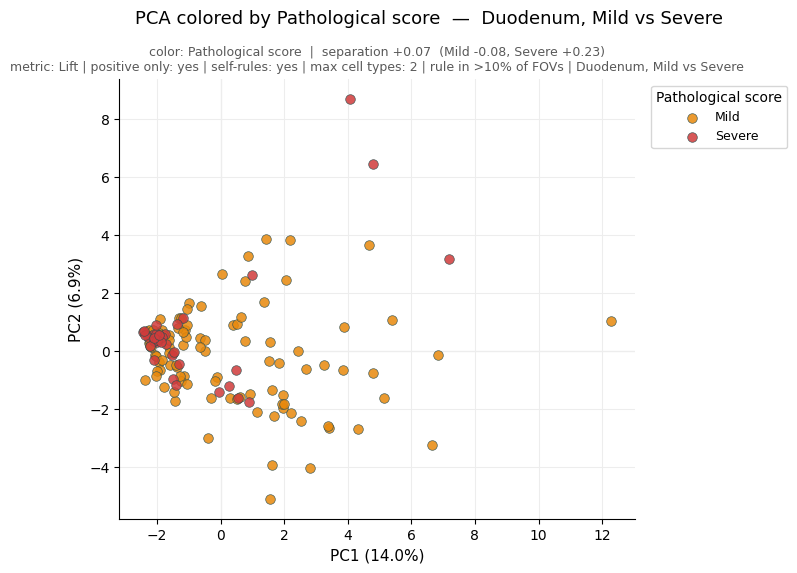

In [13]:
rs.scatter(mild_severe_duodenum, save=True);   # the clean PCA, no labels